# Taller: consulta y análisis del dataset *Students Performance*

**Asignatura:** Fundamentos para IA  
**Integrantes:** Johan Sebastian Cañon y Juan David Cadavid Divantoque

El notebook conserva la estructura propuesta en el taller y desarrolla los puntos 1 al 4.

## 1. Importación de librerías, lectura del CSV y visualización inicial

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lectura del archivo CSV.
data = pd.read_csv("StudentsPerformance.csv")

# Se muestran únicamente las primeras filas para verificar la carga.
print("Primeras filas del dataset:")
display(data.head())

Primeras filas del dataset:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2. Comprensión de las variables

En esta sección se revisan el tamaño del dataset, los nombres de las columnas, los tipos de datos y un resumen general.

In [2]:
print("=" * 70)
print(f"Número de filas: {data.shape[0]}")
print(f"Número de columnas: {data.shape[1]}")

print("\nNombres de las columnas:")
print(data.columns.tolist())

print("\nTipos de datos y valores no nulos:")
data.info()

print("\nResumen general del dataset:")
display(data.describe(include="all").T)

Número de filas: 1000
Número de columnas: 8

Nombres de las columnas:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Resumen general del dat

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,1000,2,female,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race/ethnicity,1000,5,group C,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parental level of education,1000,6,some college,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lunch,1000,2,standard,645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test preparation course,1000,2,none,642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
math score,1000.0,NaN,NaN,NaN,66.089,15.16308,0.0,57.0,66.0,77.0,100.0
reading score,1000.0,NaN,NaN,NaN,69.169,14.600192,17.0,59.0,70.0,79.0,100.0
writing score,1000.0,NaN,NaN,NaN,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


## 3. Calidad de los datos

Se comprueba la existencia de valores nulos y registros duplicados. También se aclara que `none`, en la columna del curso de preparación, es una categoría válida y no un dato faltante.

In [3]:
print("Valores nulos por columna:")
print(data.isnull().sum())

print(f"\nCantidad de filas duplicadas: {data.duplicated().sum()}")

# 'none' significa que el estudiante no realizó el curso de preparación.
print(
    "Cantidad de estudiantes sin curso de preparación:",
    (data["test preparation course"] == "none").sum()
)

Valores nulos por columna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Cantidad de filas duplicadas: 0
Cantidad de estudiantes sin curso de preparación: 642


Q1: 57.0
Q3: 77.0
IQR: 20.0
Límite inferior: 27.0
Límite superior: 107.0
Cantidad de valores atípicos: 8


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10
980,female,group B,high school,free/reduced,none,8,24,23
17,female,group B,some high school,free/reduced,none,18,32,28
787,female,group B,some college,standard,none,19,38,32
145,female,group C,some college,free/reduced,none,22,39,33
842,female,group B,high school,free/reduced,completed,23,44,36
338,female,group B,some high school,free/reduced,none,24,38,27
466,female,group D,associate's degree,free/reduced,none,26,31,38


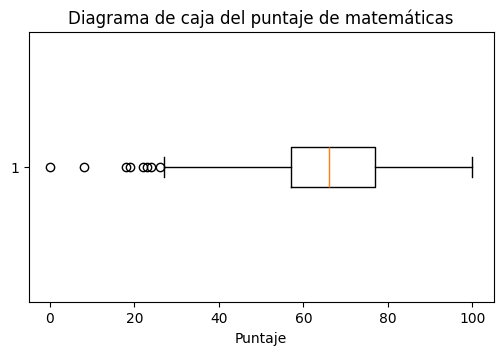

In [4]:
# Detección de valores atípicos en 'math score' mediante el método IQR.
Q1 = data["math score"].quantile(0.25)
Q3 = data["math score"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

valores_atipicos = data[
    (data["math score"] < limite_inferior) |
    (data["math score"] > limite_superior)
]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")
print(f"Cantidad de valores atípicos: {len(valores_atipicos)}")

display(valores_atipicos.sort_values("math score"))

# Gráfica básica para observar la distribución y los posibles atípicos.
plt.figure(figsize=(6, 3.5))
plt.boxplot(data["math score"], vert=False)
plt.title("Diagrama de caja del puntaje de matemáticas")
plt.xlabel("Puntaje")
plt.show()

## 4. Análisis exploratorio inicial

In [5]:
# Variables categóricas: frecuencias y porcentajes.
for columna in ["gender", "test preparation course"]:
    print("=" * 70)
    print(f"Frecuencia de {columna}:")
    print(data[columna].value_counts())

    print(f"\nPorcentaje de {columna}:")
    print((data[columna].value_counts(normalize=True) * 100).round(2))

Frecuencia de gender:
gender
female    518
male      482
Name: count, dtype: int64

Porcentaje de gender:
gender
female    51.8
male      48.2
Name: proportion, dtype: float64
Frecuencia de test preparation course:
test preparation course
none         642
completed    358
Name: count, dtype: int64

Porcentaje de test preparation course:
test preparation course
none         64.2
completed    35.8
Name: proportion, dtype: float64


In [6]:
# Variables numéricas: se toman las últimas tres columnas,
# correspondientes a matemáticas, lectura y escritura.
puntajes = data.iloc[:, -3:]

print("Resumen de los puntajes:")
display(puntajes.describe().T)

print("Promedios:")
print(puntajes.mean().round(2))

print("\nMedianas:")
print(puntajes.median())

print("\nDesviaciones estándar:")
print(puntajes.std().round(2))

Resumen de los puntajes:


,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


Promedios:
math score       66.09
reading score    69.17
writing score    68.05
dtype: float64

Medianas:
math score       66.0
reading score    70.0
writing score    69.0
dtype: float64

Desviaciones estándar:


math score       15.16
reading score    14.60
writing score    15.20
dtype: float64


In [7]:
# Relación descriptiva básica entre variables.
print("Promedio de puntajes por género:")
display(data.groupby("gender")[data.columns[-3:]].mean().round(2))

print("Promedio de puntajes según el curso de preparación:")
display(
    data.groupby("test preparation course")[data.columns[-3:]]
        .mean()
        .round(2)
)

print("Correlación entre los tres puntajes:")
display(data.iloc[:, -3:].corr().round(3))

Promedio de puntajes por género:


,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


Promedio de puntajes según el curso de preparación:


,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


Correlación entre los tres puntajes:


,math score,reading score,writing score
math score,1.000,0.818,0.803
reading score,0.818,1.000,0.955
writing score,0.803,0.955,1.000
